## Libraries

In [21]:
import os
import os.path as osp
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time 
import statistics as stat
from tabulate import tabulate

import torch
import torch.nn as nn
from torch.optim import Adam

#********************************************************#
'''
load_dataset contain lots of functions for loading several datasets and 
also there is a function as name get_ dataloader for generating a
dictionary of training, validation, and testing dataLoader.
'''
from load_dataset import get_dataset, get_dataloader

#********************************************************#
'''
As we need several arguments for training process, we store all argument in configure file. 
For using this file, you need the library'Typed Argument Parser (Tap). So you need 'pip install typed-argument-parser'. 
'''
from Configures import data_args, train_args, model_args

In [2]:
import itertools
import os

os.environ["DGLBACKEND"] = "pytorch"

import copy
import dgl
import dgl.data
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
from sklearn.metrics import roc_auc_score
from torchprofile import profile_macs


def get_model_macs(model, inputs) -> int:
    '''
    MACs are a common metric to measure the computational complexity 
    of deep neural networks, as they reflect the number of arithmetic
    operations involved in the forward pass of the model
    '''
    return profile_macs(model, inputs)


def get_sparsity(tensor: torch.Tensor) -> float:
    """
    calculate the sparsity of the given tensor
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    return 1 - float(tensor.count_nonzero()) / tensor.numel()


def get_model_sparsity(model: nn.Module) -> float:
    """
    calculate the sparsity of the given model
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    num_nonzeros, num_elements = 0, 0
    for param in model.parameters():
        num_nonzeros += param.count_nonzero()
        num_elements += param.numel()
    return 1 - float(num_nonzeros) / num_elements

def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
    """
    calculate the total number of parameters of model
    :param count_nonzero_only: only count nonzero weights
    """
    num_counted_elements = 0
    for param in model.parameters():
        if count_nonzero_only:
            num_counted_elements += param.count_nonzero()
        else:
            num_counted_elements += param.numel()
    return num_counted_elements


def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    """
    calculate the model size in bits
    :param data_width: #bits per element
    :param count_nonzero_only: only count nonzero weights
    """
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB



pseudo quantization
---

The following code is for pseudo quantization.Pseudo Quantization is used to simulate the effects of quantization on a model without actually quantizing the model's weights. (i.e. rounding to the nearest quantized value and then dequantizing back to a float.)

In [3]:
# core quantization method (simulated quantization)
def pseudo_quantize_tensor(w, n_bit=4, q_group_size=-1):
    org_w_shape = w.shape
    if q_group_size > 0:
        assert org_w_shape[-1] % q_group_size == 0
        w = w.reshape(-1, q_group_size)

    assert w.dim() == 2

    # Calculate the maximum (\alpha) and minimum values (\beta) in the tensor.
    max_val = w.amax(dim=1, keepdim=True)
    assert max_val.dim() == 2 and max_val.size(0) == w.size(0) and max_val.size(1) == 1
    min_val = w.amin(dim=1, keepdim=True)
    assert min_val.dim() == 2 and min_val.size(0) == w.size(0) and min_val.size(1) == 1

    # Calculate the scale factor and zero point.  (Formula 1 & 2)
    max_int = 2 ** n_bit - 1
    scales = (max_val - min_val).clamp(min=1e-5) / max_int
    assert scales.shape == max_val.shape
    zeros = (-torch.round(min_val / scales)).clamp_(0, max_int)
    assert scales.shape == min_val.shape

    assert torch.isnan(scales).sum() == 0
    assert torch.isnan(w).sum() == 0

    # Quantize W: Map values in the range [\beta, \alpha] to lie within [0, 2^b - 1] (Formula 3)
    w = torch.clamp(torch.round(w / scales) + zeros, 0, max_int)
    assert w.dim() == 2 and w.size(0) == scales.size(0) and w.size(1) == q_group_size

    # Dequantize W (pseudo quantization, the inverse transformation of Formula 3)
    w = (w - zeros) * scales
    assert w.dim() == 2 and w.size(0) == scales.size(0) and w.size(1) == q_group_size

    assert torch.isnan(w).sum() == 0

    w = w.reshape(org_w_shape)
    return w

@torch.no_grad()
def pseudo_quantize_model_weight(model, w_bit):
    for n, m in model.named_parameters():
        #if isinstance(m, nn.Linear):
        q_group_size=m.data.shape[-1]
        if 'lin.weight' in n:
            m.data = pseudo_quantize_tensor(m.data, n_bit=w_bit, q_group_size=q_group_size)
            #print(m.data)

The Blood-brain barrier penetration (BBBP)
--------------------------------------------------------------

### start loading data

In [4]:
print(data_args.dataset_name)
print(data_args.dataset_dir)



bbbp
/datasets


In [5]:
dataset = get_dataset(data_args.dataset_dir, data_args.dataset_name)
input_dim = dataset.num_node_features
output_dim = int(dataset.num_classes)


print(input_dim)
print(output_dim)

9
2


C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\data\in_memory_dataset.py:183: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


In [6]:
print(dataset[59].edge_index.numpy())
dataset[59].edge_index.numpy().size==0

[]


True

### Data Analysis

In [ ]:
avg_nodes = 0.0
avg_edge_index = 0.0
for i in range(len(dataset)):
    avg_nodes += dataset[i].x.shape[0]
    avg_edge_index += dataset[i].edge_index.shape[1]
avg_nodes /= len(dataset)
avg_edge_index /= len(dataset)
print(f"graphs {len(dataset)}, avg_nodes{avg_nodes :.4f}, avg_edge_index_{avg_edge_index/2 :.4f}")

best_acc = 0.0
data_size = len(dataset)
print(f'The total num of dataset is {data_size}')



In [ ]:


# Read the CSV file
df = pd.read_csv('datasets/bbbp/raw/BBBP.csv')

# Print the shape of the dataset
print("The shape of the dataset is:", df.shape)

# Print the columns of the dataset
print("The columns of the dataset are:", df.columns)

# Print the summary statistics of the dataset
print("The summary statistics of the dataset are:")
print(df.describe())

# Print some sample rows of the dataset
print("Some sample rows of the dataset are:")
df.head(5)

In [ ]:
df["smiles"][59:65]

### Visualizing

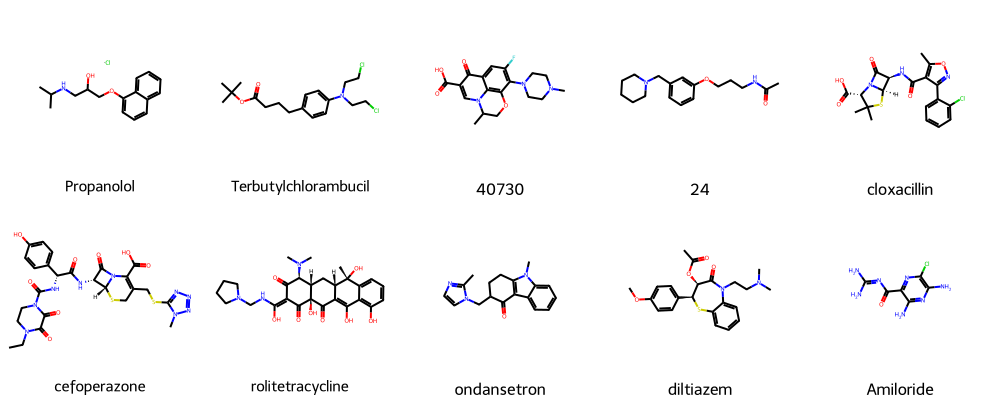

In [12]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# Read the CSV file
df = pd.read_csv('datasets/bbbp/raw/BBBP.csv')

# Extract the SMILES strings and names of the first 10 compounds
smiles_list = df["smiles"][:10].tolist()
name_list = df["name"][:10].tolist()

# Convert the SMILES strings into RDKit molecule objects
mol_list = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

# Create a grid image with 2 rows and 5 columns and put the names as legends
img = Draw.MolsToGridImage(mol_list, molsPerRow=5, legends=name_list)
img

### Preprocessing and cleaning dataset

In [7]:
#cleaned_dataset = [graph for graph in dataset if graph.edge_index.numpy()!=[]]
cleaned_dataset = [graph for graph in dataset if graph.edge_index.numpy().size> 0]
cleaned_dataset_len=len(cleaned_dataset)
print(f'The number of graphs after cleaning dataset is: {cleaned_dataset_len}')

The number of graphs after cleaning dataset is: 2039


In [8]:
dataloader=get_dataloader(cleaned_dataset, batch_size=train_args.batch_size, random_split_flag=True, data_split_ratio=[0.8, 0.1, 0.1], seed=2)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


### Traninig Process

In [25]:
model_args.model_name.lower()

'gcn'

In [9]:
from GCN import GCNNet

def get_model(input_dim, output_dim, model_args):
    if model_args.model_name.lower() == 'gcn':
        return GCNNet(input_dim, output_dim, model_args)
    elif model_args.model_name.lower() == 'gat':
        return GATNet(input_dim, output_dim, model_args)
    elif model_args.model_name.lower() == 'gin':
        return GINNet(input_dim, output_dim, model_args)
    else:
        raise NotImplementedError
        


class GnnBase(nn.Module):
    def __init__(self):
        super(GnnBase, self).__init__()

    def forward(self, data):
        data = data.to(self.device)
        logits, prob, emb = self.model(data)
        return logits, prob, emb

    def update_state_dict(self, state_dict):
        original_state_dict = self.state_dict()
        loaded_state_dict = dict()
        for k, v in state_dict.items():
            if k in original_state_dict.keys():
                loaded_state_dict[k] = v
        self.load_state_dict(loaded_state_dict)

    def to_device(self):
        self.to(self.device)

    def save_state_dict(self):
        pass


class GnnNets(GnnBase):
    def __init__(self, input_dim, output_dim, model_args):
        super(GnnNets, self).__init__()
        self.model = get_model(input_dim, output_dim, model_args)
        self.device = model_args.device

    def forward(self, data):
        data = data.to(self.device)
        logits, prob, emb = self.model(data)
        return logits, prob, emb



In [10]:
gnnNets = GnnNets(input_dim, output_dim, model_args)
gnnNets.to_device()
criterion = nn.CrossEntropyLoss()
optimizer = Adam(gnnNets.parameters(), lr=train_args.learning_rate, weight_decay=train_args.weight_decay)

In [11]:
def evaluate_GC(eval_dataloader, gnnNets, criterion):
    acc = []
    loss_list = []
    gnnNets.eval()
    with torch.no_grad():
        for batch in eval_dataloader:
            logits, probs, _ = gnnNets(batch)
            loss = criterion(logits, batch.y)

            ## record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            acc.append(prediction.eq(batch.y).cpu().numpy())

        eval_state = {'loss': np.average(loss_list),
                      'acc': np.concatenate(acc, axis=0).mean()}

    return eval_state


def test_GC(test_dataloader, gnnNets, criterion):
    acc = []
    loss_list = []
    pred_probs = []
    predictions = []
    gnnNets.eval()
    with torch.no_grad():
        for batch in test_dataloader:
            logits, probs, _ = gnnNets(batch)
            loss = criterion(logits, batch.y)

            # record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            acc.append(prediction.eq(batch.y).cpu().numpy())
            predictions.append(prediction)
            pred_probs.append(probs)

    test_state = {'loss': np.average(loss_list),
                  'acc': np.average(np.concatenate(acc, axis=0).mean())}

    pred_probs = torch.cat(pred_probs, dim=0).cpu().detach().numpy()
    predictions = torch.cat(predictions, dim=0).cpu().detach().numpy()
    return test_state, pred_probs, predictions

def save_best(ckpt_dir, epoch, gnnNets, model_name, eval_acc, is_best):
    print('saving....')
    gnnNets.to('cpu')
    state = {
        'net': gnnNets.state_dict(),
        'epoch': epoch,
        'acc': eval_acc
    }
    pth_name = f"{model_name}_latest.pth"
    best_pth_name = f'{model_name}_best.pth'
    ckpt_path = os.path.join(ckpt_dir, pth_name)
    torch.save(state, ckpt_path)
    if is_best:
        shutil.copy(ckpt_path, os.path.join(ckpt_dir, best_pth_name))
    gnnNets.to_device()

### save path for model

In [12]:

if not os.path.isdir('checkpoint'):
    os.mkdir('checkpoint')
if not os.path.isdir(os.path.join('checkpoint', data_args.dataset_name)):
    os.mkdir(os.path.join('checkpoint', f"{data_args.dataset_name}"))
ckpt_dir = f"./checkpoint/{data_args.dataset_name}/"



#### Training

In [ ]:
best_acc=0
early_stop_count = 0

for epoch in range(100):
  
    acc=[]
    loss_list = []
    gnnNets.train()
    for batch in dataloader['train']:
        logits, probs, _ = gnnNets(batch)
        loss = criterion(logits, batch.y)

        # optimization
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(gnnNets.parameters(), clip_value=2.0)
        optimizer.step()

        ## record
        _, prediction = torch.max(logits, -1)
        loss_list.append(loss.item())
        acc.append(prediction.eq(batch.y).cpu().numpy())
        
    # report train msg
    print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
          f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
 
   
    # report eval msg
    eval_state = evaluate_GC(dataloader['eval'], gnnNets, criterion)
    print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {eval_state['acc']:.3f}")
    
    # only save the best model
    is_best = (eval_state['acc'] > best_acc)

    if eval_state['acc'] > best_acc:
        early_stop_count = 0
    else:
        early_stop_count += 1

    if early_stop_count > train_args.early_stopping:
        break

    if is_best:
        best_acc = eval_state['acc']
        early_stop_count = 0
    if is_best or epoch % train_args.save_epoch == 0:
        save_best(ckpt_dir, epoch, gnnNets, model_args.model_name, eval_state['acc'], is_best)

print(f"The best validation accuracy is {best_acc}.")
  


In [34]:
 print(f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")

Acc: 0.883


### Evaluation 

In [15]:
print(f"The best validation accuracy is {best_acc}.")
# report test msg
checkpoint = torch.load(os.path.join(ckpt_dir, f'{model_args.model_name}_best.pth'))
gnnNets.update_state_dict(checkpoint['net'])
test_state, _, _ = test_GC(dataloader['test'], gnnNets, criterion)
print(f"Test: | Loss: {test_state['loss']:.3f} | Acc: {test_state['acc']:.3f}")

t0=time.time()
test_state, _, _ = test_GC(dataloader['test'], gnnNets, criterion)
base_model_accuracy= test_state['acc']
t1=time.time()
t_base_model=t1 - t0
###
base_model_size = get_model_size(gnnNets,count_nonzero_only=True)
num_parm_base_model=get_num_parameters(gnnNets, count_nonzero_only=True)
###   
print(f"dense model has accuracy on test set={base_model_accuracy:.2f}%")
print(f"dense model has size={base_model_size/MiB:.2f} MiB")
print(f"The time inference of base model is ={t_base_model}") 
print(f"The number of parametrs of base model is:{num_parm_base_model}")   


dense model has accuracy on test set=0.82%
dense model has size=0.13 MiB
The time inference of base model is =0.13153696060180664
The number of parametrs of base model is:34531


In [17]:
pseudo_quantize_model_weight(gnnNets, w_bit=3)


In [18]:
best_acc=0
early_stop_count = 0

for epoch in range(100):
  
    acc=[]
    loss_list = []
    gnnNets.train()
    for batch in dataloader['train']:
        logits, probs, _ = gnnNets(batch)
        loss = criterion(logits, batch.y)

        # optimization
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(gnnNets.parameters(), clip_value=2.0)
        optimizer.step()

        ## record
        _, prediction = torch.max(logits, -1)
        loss_list.append(loss.item())
        acc.append(prediction.eq(batch.y).cpu().numpy())
        
    # report train msg
    print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
          f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
 
   
    # report eval msg
    eval_state = evaluate_GC(dataloader['eval'], gnnNets, criterion)
    print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {eval_state['acc']:.3f}")
    
    # only save the best model
    is_best = (eval_state['acc'] > best_acc)

    if eval_state['acc'] > best_acc:
        early_stop_count = 0
    else:
        early_stop_count += 1

    if early_stop_count > train_args.early_stopping:
        break

    if is_best:
        best_acc = eval_state['acc']
        early_stop_count = 0
    if is_best or epoch % train_args.save_epoch == 0:
        save_best(ckpt_dir, epoch, gnnNets, model_args.model_name, eval_state['acc'], is_best)

print(f"The best validation accuracy is {best_acc}.")
  


Train Epoch:0  |Loss: 0.368 | Acc: 0.849
Eval Epoch: 0 | Loss: 0.307 | Acc: 0.852
saving....
Train Epoch:1  |Loss: 0.330 | Acc: 0.865
Eval Epoch: 1 | Loss: 0.338 | Acc: 0.862
saving....
Train Epoch:2  |Loss: 0.327 | Acc: 0.868
Eval Epoch: 2 | Loss: 0.327 | Acc: 0.877
saving....
Train Epoch:3  |Loss: 0.317 | Acc: 0.876
Eval Epoch: 3 | Loss: 0.299 | Acc: 0.882
saving....
Train Epoch:4  |Loss: 0.313 | Acc: 0.879
Eval Epoch: 4 | Loss: 0.332 | Acc: 0.852
Train Epoch:5  |Loss: 0.302 | Acc: 0.876
Eval Epoch: 5 | Loss: 0.295 | Acc: 0.892
saving....
Train Epoch:6  |Loss: 0.311 | Acc: 0.872
Eval Epoch: 6 | Loss: 0.306 | Acc: 0.867
Train Epoch:7  |Loss: 0.312 | Acc: 0.877
Eval Epoch: 7 | Loss: 0.355 | Acc: 0.842
Train Epoch:8  |Loss: 0.309 | Acc: 0.871
Eval Epoch: 8 | Loss: 0.309 | Acc: 0.862
Train Epoch:9  |Loss: 0.318 | Acc: 0.868
Eval Epoch: 9 | Loss: 0.308 | Acc: 0.872
Train Epoch:10  |Loss: 0.301 | Acc: 0.880
Eval Epoch: 10 | Loss: 0.304 | Acc: 0.901
saving....
Train Epoch:11  |Loss: 0.309 |

Train Epoch:96  |Loss: 0.205 | Acc: 0.915
Eval Epoch: 96 | Loss: 0.293 | Acc: 0.862
Train Epoch:97  |Loss: 0.204 | Acc: 0.926
Eval Epoch: 97 | Loss: 0.304 | Acc: 0.862
Train Epoch:98  |Loss: 0.192 | Acc: 0.929
Eval Epoch: 98 | Loss: 0.301 | Acc: 0.867
Train Epoch:99  |Loss: 0.185 | Acc: 0.929
Eval Epoch: 99 | Loss: 0.300 | Acc: 0.872
The best validation accuracy is 0.9064039408866995.


In [20]:
import time
print(f"The best validation accuracy is {best_acc}.")
# report test msg
checkpoint = torch.load(os.path.join(ckpt_dir, f'{model_args.model_name}_best.pth'))
gnnNets.update_state_dict(checkpoint['net'])

t0=time.time()
test_state, _, _ = test_GC(dataloader['test'], gnnNets, criterion)
after_awq_model_accuracy= test_state['acc']
t1=time.time()
after_awq_model=t1 - t0
###
model_size_after_awq = get_model_size(gnnNets,count_nonzero_only=True)
num_parm_after_awq=get_num_parameters(gnnNets, count_nonzero_only=True)
###   
print(f"awq model has accuracy on test set={after_awq_model_accuracy:.2f}%")
print(f"awq model has size={model_size_after_awq/MiB:.2f} MiB")
print(f"The time inference of awq model is ={after_awq_model}") 
print(f"The number of parametrs of awq model is:{num_parm_after_awq}")   

            

The best validation accuracy is 0.9064039408866995.
AWQ model has accuracy on test set=0.82%
AWQ model has size=0.11 MiB
The time inference of AWQ model is =0.11592459678649902
The number of parametrs of AWQ model is:27858


## Manual Measurement

In [16]:

Eva_final=dict()

Base_model_accuracy=[]
T_base_model=[]
Num_parm_base_model=[]
Base_model_size=[]

AWQ_model_accuracy=[]
T_AWQ_model=[]
Num_parm_AWQ_model=[]
AWQ_model_size=[]

AWQ_finetune_model_accuracy=[]
T_AWQ_finetune_model=[]
Num_parm_AWQ_finetune_model=[]
AWQ_finetune_model_size=[]

In [17]:

import glob
import os

for i in range(5):
    #files = glob.glob('*.pth')
    files = glob.glob(os.path.join(ckpt_dir, '*.pth'))
    for f in files:
     #if f!='{}.pth'.format(best_model):
            os.remove(f)
    print(f'The iteration is :{i+1} ')
    num_epoch=100
    Eva=dict()
    
    print(f'Training and evaluation before Quatization ')
    best_acc=0
    early_stop_count = 0
    model = GnnNets(input_dim, output_dim, model_args)
    model.to_device()
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=train_args.learning_rate, weight_decay=train_args.weight_decay)
   
    for epoch in range(num_epoch):
  
            acc=[]
            loss_list = []
            gnnNets.train()
            for batch in dataloader['train']:
                logits, probs, _ = gnnNets(batch)
                loss = criterion(logits, batch.y)

                # optimization
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_value_(gnnNets.parameters(), clip_value=2.0)
                optimizer.step()

                ## record
                _, prediction = torch.max(logits, -1)
                loss_list.append(loss.item())
                acc.append(prediction.eq(batch.y).cpu().numpy())
              
            eval_state = evaluate_GC(dataloader['eval'], model, criterion)
            accuracy=eval_state['acc']

            if (epoch+1) % 20 == 0:   
                # report train msg
                print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
                      f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
                print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {accuracy:.3f}")
                # only save the best model
            is_best = (eval_state['acc'] > best_acc)

            if eval_state['acc'] > best_acc:
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count > train_args.early_stopping:
                break

            if is_best:
                best_acc = eval_state['acc']
                early_stop_count = 0
            if is_best or epoch % train_args.save_epoch == 0:
                save_best(ckpt_dir, epoch, gnnNets, model_args.model_name, eval_state['acc'], is_best)

    print(f"The best validation accuracy is {best_acc}.")
   
    checkpoint = torch.load(os.path.join(ckpt_dir, f'{model_args.model_name}_best.pth'))
    gnnNets.update_state_dict(checkpoint['net'])


    t0=time.time()
    test_state, _, _ = test_GC(dataloader['test'], gnnNets, criterion)
    base_model_accuracy= test_state['acc']
    t1=time.time()
    t_base_model=t1 - t0
    ###
    base_model_size = get_model_size(gnnNets,count_nonzero_only=True)
    num_parm_base_model=get_num_parameters(gnnNets, count_nonzero_only=True)
    ###   
    print(f"base model has accuracy on test set={base_model_accuracy:.2f}%")
    print(f"base model has size={base_model_size/MiB:.2f} MiB")
    print(f"The time inference of base model is ={t_base_model}") 
    print(f"The number of parametrs of base model is:{num_parm_base_model}")  



    #Update my Eva dictionary
    Eva.update({'base model accuracy': base_model_accuracy,
                'time inference of base model': t_base_model,
                'number parmameters of base model': num_parm_base_model,
                'size of base model': base_model_size})

    print('_______________________________________________________')
    print(f'Quantization')
    pseudo_quantize_model_weight(gnnNets, w_bit=3)
    # Result
    t0=time.time()
    test_state, _, _ = test_GC(dataloader['test'], model, criterion)
    awq_model_accuracy= test_state['acc']
    t1=time.time()
    t_awq_model=t1 - t0
    ###
    awq_model_size = get_model_size(model,count_nonzero_only=True)
    num_parm_awq_model=get_num_parameters(model, count_nonzero_only=True)
    ###   
    print(f"awq model has accuracy on test set={awq_model_accuracy:.2f}%")
    print(f"awq model has size={awq_model_size/MiB:.2f} MiB")
    print(f"The time inference of awq model is ={t_awq_model}") 
    print(f"The number of parametrs of awq model is:{num_parm_awq_model}")
    print(f"awq model has size={awq_model_size/MiB:.2f} MiB, "
          f"which is {base_model_size/awq_model_size:.2f} X smaller than "
          f"the {base_model_size/MiB:.2f} MiB dense model")

    #Update my Eva dictionary
    Eva.update({'awq model accuracy': awq_model_accuracy,
                'time inference of awq model': t_awq_model,
                'number parmameters of awq model': num_parm_awq_model,
                'size of awq model': awq_model_size})
    
    print('_______________________________________________________')
    print(f'Finetuning Q Model')
    best_acc=0
    early_stop_count = 0

    for epoch in range(num_epoch):

        acc=[]
        loss_list = []
        gnnNets.train()
        for batch in dataloader['train']:
            logits, probs, _ = gnnNets(batch)
            loss = criterion(logits, batch.y)

            # optimization
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_value_(gnnNets.parameters(), clip_value=2.0)
            optimizer.step()

            ## record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            acc.append(prediction.eq(batch.y).cpu().numpy())

        eval_state = evaluate_GC(dataloader['eval'], model, criterion)
        accuracy=eval_state['acc']

        if (epoch+1) % 20 == 0:   
                # report train msg
                print(f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | "
                      f"Acc: {np.concatenate(acc, axis=0).mean():.3f}")
                print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | Acc: {accuracy:.3f}")
           

        # only save the best model
        is_best = (eval_state['acc'] > best_acc)

        if eval_state['acc'] > best_acc:
            early_stop_count = 0
        else:
            early_stop_count += 1

        if early_stop_count > train_args.early_stopping:
            break

        if is_best:
            best_acc = eval_state['acc']
            early_stop_count = 0
        if is_best or epoch % train_args.save_epoch == 0:
            save_best(ckpt_dir, epoch, gnnNets, model_args.model_name, eval_state['acc'], is_best)

    print(f"The best validation accuracy is {best_acc}.")
    
    checkpoint = torch.load(os.path.join(ckpt_dir, f'{model_args.model_name}_best.pth'))
    gnnNets.update_state_dict(checkpoint['net'])
    t0=time.time()
    test_state, _, _ = test_GC(dataloader['test'], gnnNets, criterion)
    awq_finetune_model_accuracy= test_state['acc']
    t1=time.time()
    t_awq_finetune_model=t1 - t0
    ###
    awq_finetune_model_size = get_model_size(model,count_nonzero_only=True)
    num_parm_awq_finetune_model=get_num_parameters(model, count_nonzero_only=True)
    ###   
    print(f"awq model has accuracy on test set={awq_finetune_model_accuracy:.2f}%")
    print(f"awq model has size={awq_finetune_model_size/MiB:.2f} MiB")
    print(f"The time inference of awq model is ={t_awq_finetune_model}") 
    print(f"The number of parametrs of awq model is:{num_parm_awq_finetune_model}")
    print(f"awq model has size={awq_finetune_model_size/MiB:.2f} MiB, "
    f" which is {base_model_size/awq_finetune_model_size:.2f} X smaller than "
    f" the {base_model_size/MiB:.2f} MiB dense model")


     #Update my Eva dictionary
    Eva.update({'awq and finetune model accuracy': awq_finetune_model_accuracy,
                'time inference of awq and finetune model': t_awq_finetune_model,
                'number parmameters of awq and finetune model': num_parm_awq_finetune_model,
                'size of awq and finetune model':  awq_finetune_model_size})


  


    Base_model_accuracy.append(Eva['base model accuracy'])
    T_base_model.append(Eva['time inference of base model'])
    Num_parm_base_model.append(int(Eva['number parmameters of base model']))
    Base_model_size.append(int(Eva['size of base model']))

    AWQ_model_accuracy.append(Eva['awq model accuracy'])
    T_AWQ_model.append(Eva['time inference of awq model'])
    Num_parm_AWQ_model.append(int(Eva['number parmameters of awq model']))
    AWQ_model_size.append(int(Eva['size of awq model']))

    AWQ_finetune_model_accuracy.append(Eva['awq and finetune model accuracy'])
    T_AWQ_finetune_model.append(Eva['time inference of awq and finetune model'])
    Num_parm_AWQ_finetune_model.append(int(Eva['number parmameters of awq and finetune model']))
    AWQ_finetune_model_size.append(int(Eva['size of awq and finetune model']))




The iteration is :1 
Training and evaluation before Quatization 
saving....
saving....
Train Epoch:19  |Loss: 0.612 | Acc: 0.773
Eval Epoch: 19 | Loss: 0.712 | Acc: 0.271
saving....
saving....
Train Epoch:39  |Loss: 0.613 | Acc: 0.773
Eval Epoch: 39 | Loss: 0.712 | Acc: 0.271
saving....
saving....
Train Epoch:59  |Loss: 0.613 | Acc: 0.773
Eval Epoch: 59 | Loss: 0.712 | Acc: 0.271
saving....
saving....
Train Epoch:79  |Loss: 0.613 | Acc: 0.773
Eval Epoch: 79 | Loss: 0.712 | Acc: 0.271
saving....
saving....
Train Epoch:99  |Loss: 0.613 | Acc: 0.773
Eval Epoch: 99 | Loss: 0.712 | Acc: 0.271
The best validation accuracy is 0.270935960591133.
base model has accuracy on test set=0.72%
base model has size=0.11 MiB
The time inference of base model is =0.14998340606689453
The number of parametrs of base model is:29467
_______________________________________________________
Quantization
awq model has accuracy on test set=0.29%
awq model has size=0.13 MiB
The time inference of awq model is =0.159

saving....
saving....
Train Epoch:19  |Loss: 0.629 | Acc: 0.773
Eval Epoch: 19 | Loss: 0.554 | Acc: 0.754
saving....
saving....
Train Epoch:39  |Loss: 0.629 | Acc: 0.773
Eval Epoch: 39 | Loss: 0.554 | Acc: 0.754
saving....
saving....
Train Epoch:59  |Loss: 0.630 | Acc: 0.773
Eval Epoch: 59 | Loss: 0.554 | Acc: 0.754
saving....
saving....
Train Epoch:79  |Loss: 0.629 | Acc: 0.773
Eval Epoch: 79 | Loss: 0.554 | Acc: 0.754
saving....
saving....
Train Epoch:99  |Loss: 0.629 | Acc: 0.773
Eval Epoch: 99 | Loss: 0.554 | Acc: 0.754
The best validation accuracy is 0.7536945812807881.
base model has accuracy on test set=0.72%
base model has size=0.11 MiB
The time inference of base model is =0.1000053882598877
The number of parametrs of base model is:29467
_______________________________________________________
Quantization
awq model has accuracy on test set=0.72%
awq model has size=0.13 MiB
The time inference of awq model is =0.10000467300415039
The number of parametrs of awq model is:34178
awq 

In [19]:
Eva_final=dict()
base_model_accuracy_mean = stat.mean(Base_model_accuracy)
base_model_accuracy_std =  stat.stdev(Base_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)

Eva_final.update({'base model accuracy':float(format(base_model_accuracy_mean, '.3f'))})
Eva_final.update({'Std of base model accuracy':float(format(base_model_accuracy_std, '.3f'))})
                 
t_base_model_mean =stat.mean(T_base_model)
t_base_model_std =stat.stdev(T_base_model)  
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of base model':float(format(t_base_model_mean, '.3f'))})
Eva_final.update({'Std of time inference of base model':float(format(t_base_model_std, '.3f'))})


num_parm_base_model_mean = stat.mean(Num_parm_base_model)
num_parm_base_model_std = stat.stdev(Num_parm_base_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of base model':num_parm_base_model_mean})
Eva_final.update({'Std of number parmameters of base model':num_parm_base_model_std})

base_model_size_mean = stat.mean(Base_model_size)
base_model_size_std = stat.stdev(Base_model_size)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'base_model_size':base_model_size_mean})
Eva_final.update({'Std of base_model_size':base_model_size_std})

#################################


AWQ_model_accuracy_mean =stat.mean(AWQ_model_accuracy)
AWQ_model_accuracy_std = stat.stdev(AWQ_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ model accuracy':float(format(AWQ_model_accuracy_mean, '.3f'))})
Eva_final.update({'Std of AWQ model accuracy':float(format(AWQ_model_accuracy_std, '.3f'))})
                 

t_AWQ_model_mean = stat.mean(T_AWQ_model)
t_AWQ_model_std =stat.stdev(T_AWQ_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of AWQ model':float(format(t_AWQ_model_mean, '.3f'))})
Eva_final.update({'Std of time inference of AWQ model':float(format(t_AWQ_model_std, '.3f'))})

num_parm_AWQ_model_mean = stat.mean(Num_parm_AWQ_model)
num_parm_AWQ_model_std = stat.stdev(Num_parm_AWQ_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of AWQ model':num_parm_AWQ_model_mean})
Eva_final.update({'Std of number parmameters of AWQ model':num_parm_AWQ_model_std})

AWQ_model_size_mean =stat.mean( AWQ_model_size)
AWQ_model_size_std = stat.stdev(AWQ_model_size)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ model size':AWQ_model_size_mean})
Eva_final.update({'Std of AWQ_model_size':AWQ_model_size_std })


#################################
#################################
AWQ_finetune_model_accuracy_mean =stat.mean(AWQ_finetune_model_accuracy)
AWQ_finetune_model_accuracy_std = stat.stdev(AWQ_finetune_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ finetune model accuracy':float(format(AWQ_finetune_model_accuracy_mean, '.3f'))})
Eva_final.update({'Std of AWQ finetune model accuracy':float(format(AWQ_finetune_model_accuracy_std, '.3f'))})                 

t_AWQ_finetune_model_mean =stat.mean(T_AWQ_finetune_model)
t_AWQ_finetune_model_std =stat.stdev(T_AWQ_finetune_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of AWQ finetune model':float(format(t_AWQ_finetune_model_mean,'.3f'))})
Eva_final.update({'Std of time inference of AWQ finetune model':float(format(t_AWQ_finetune_model_std,'.3f'))})

num_parm_AWQ_finetune_model_mean =stat.mean(Num_parm_AWQ_finetune_model)
num_parm_AWQ_finetune_model_std = stat.stdev(Num_parm_AWQ_finetune_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of AWQ finetune model':num_parm_AWQ_finetune_model_mean})
Eva_final.update({'Std of number parmameters of AWQ finetune model':num_parm_AWQ_finetune_model_std })

AWQ_finetune_model_size_mean = stat.mean(AWQ_finetune_model_size)
AWQ_finetune_model_size_std = stat.stdev(AWQ_finetune_model_size)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ finetune model size':AWQ_finetune_model_size_mean})
Eva_final.update({'Std of AWQ finetune model size':AWQ_finetune_model_size_std})



print(f"All measurement about Quatization process ")   
Eva_final

All measurement about Quatization process 


{'base model accuracy': 0.717,
 'Std of base model accuracy': 0.0,
 'time inference of base model': 0.11,
 'Std of time inference of base model': 0.022,
 'number parmameters of base model': 29467,
 'Std of number parmameters of base model': 0.0,
 'base_model_size': 942944,
 'Std of base_model_size': 0.0,
 'AWQ model accuracy': 0.459,
 'Std of AWQ model accuracy': 0.236,
 'time inference of AWQ model': 0.118,
 'Std of time inference of AWQ model': 0.027,
 'number parmameters of AWQ model': 34178,
 'Std of number parmameters of AWQ model': 0.0,
 'AWQ model size': 1093696,
 'Std of AWQ_model_size': 0.0,
 'AWQ finetune model accuracy': 0.717,
 'Std of AWQ finetune model accuracy': 0.0,
 'time inference of AWQ finetune model': 0.098,
 'Std of time inference of AWQ finetune model': 0.009,
 'number parmameters of AWQ finetune model': 34178,
 'Std of number parmameters of AWQ finetune model': 0.0,
 'AWQ finetune model size': 1093696,
 'Std of AWQ finetune model size': 0.0}

In [27]:
All measurement about Quatization process 

{'base model accuracy': 0.717,
 'Std of base model accuracy': 0.0,
 'time inference of base model': 0.11,
 'Std of time inference of base model': 0.022,
 'number parmameters of base model': 29467,
 'Std of number parmameters of base model': 0.0,
 'base_model_size': 942944,
 'Std of base_model_size': 0.0,
 'AWQ model accuracy': 0.459,
 'Std of AWQ model accuracy': 0.236,
 'time inference of AWQ model': 0.118,
 'Std of time inference of AWQ model': 0.027,
 'number parmameters of AWQ model': 34178,
 'Std of number parmameters of AWQ model': 0.0,
 'AWQ model size': 1093696,
 'Std of AWQ_model_size': 0.0,
 'AWQ finetune model accuracy': 0.717,
 'Std of AWQ finetune model accuracy': 0.0,
 'time inference of AWQ finetune model': 0.098,
 'Std of time inference of AWQ finetune model': 0.009,
 'number parmameters of AWQ finetune model': 34178,
 'Std of number parmameters of AWQ finetune model': 0.0,
 'AWQ finetune model size': 1093696,
 'Std of AWQ finetune model size': 0.0}

SyntaxError: invalid syntax (491966360.py, line 1)

In [31]:
# Create a table
table_data = [Base_model_accuracy,T_base_model,Num_parm_base_model, Base_model_size,
              AWQ_model_accuracy, T_AWQ_model, Num_parm_AWQ_model, AWQ_model_size,
              AWQ_finetune_model_accuracy,T_AWQ_finetune_model, Num_parm_AWQ_finetune_model, AWQ_finetune_model_size]
headers=['1', '2', '3', '4','5']
# Print the table
tabulate(table_data, headers, tablefmt='fancy_grid')
# New column data
first_column_data =  ['Base_model_accuracy','T_base_model','Num_parm_base_model', 'Base_model_size',
                     'AWQ_model_accuracy', 'T_AWQ_model', 'Num_parm_AWQ_model', 'AWQ_model_size',
                     'AWQ_finetune_model_accuracy','T_AWQ_finetune_model', 'Num_parm_AWQ_finetune_model','AWQ_finetune_model_size']

# Add a custom index column
headers=['1', '2', '3', '4', '5']
table_with_index = tabulate(table_data, headers=['parameters'] + headers,
                            showindex=first_column_data, tablefmt="fancy_grid", numalign="center")

# Print the extended table
print(table_with_index)

╒═════════════════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╕
│ parameters                  │     1      │     2      │     3      │     4      │     5      │
╞═════════════════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ Base_model_accuracy         │  0.717073  │  0.717073  │  0.717073  │  0.717073  │  0.717073  │
├─────────────────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┤
│ T_base_model                │  0.149983  │  0.100019  │ 0.0999801  │  0.100012  │  0.100005  │
├─────────────────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┤
│ Num_parm_base_model         │   29467    │   29467    │   29467    │   29467    │   29467    │
├─────────────────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┤
│ Base_model_size             │   942944   │   942944   │   942944   │   942944   │   942944   │
├─────────────────────────────

In [32]:
# Save the table to a text file with UTF-8 encoding
with open("table.txt", "w", encoding="utf-8") as outputfile:
    outputfile.write(table_with_index)

print("Table saved to 'table.txt'")

Table saved to 'table.txt'
